In standard programming, jab ek function bahut bada ho jata hai, hum use chote helper functions mein tod dete hain taaki code clean rahe.
LangGraph mein bhi exactly yahi hota hai. Jab aapka AI Graph bahut complex ho jata hai (jisme loops, multiple condition checks, aur bohot saare nodes hote hain), tab hum ek chota independent graph banate hain aur usay main graph mein as a single Node attach kar dete hain. Is chote independent graph ko "Subgraph" kehte hain.


Complexity Management (Code Cleanliness): Agar aap ek AI travel agent bana rahe ho, aur "Hotel Booking" process apne aap mein ek 5-step process hai (Search ➔ Read Reviews ➔ Check Price ➔ Pay ➔ Confirm), toh is poore process ko main graph mein daalne se code ka "spaghetti" ban jayega. Isko ek Subgraph mein daalne se main graph clean rehta hai.

Reusability (Ek baar likho, baar-baar use karo): Ek baar aapne hotel_booking_subgraph bana liya, toh aap isey apne kisi bhi dusre AI project ya doosre main graph mein directly import karke use kar sakte ho.

Team Collaboration: Software companies mein ek developer "Flight Graph" par kaam kar sakta hai, doosra "Hotel Graph" par, aur third developer un dono Subgraphs ko ek Main Graph mein connect kar dega.



In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

In [2]:
class TravelState(TypedDict):
    query: str
    hotel_status: str
    final_plan: str

### SUBGRAPH

In [5]:
def hotel_search(state: TravelState):
    print("   [Subgraph] 🔍 Searching hotels for:", state["query"])
    return {"hotel_status": "Found Taj Hotel"}

def hotel_book(state: TravelState):
    print("   [Subgraph] 🛎️ Booking the selected hotel...")
    return {"hotel_status": "Taj Hotel Confirmed"}

In [6]:
hotel_builder = StateGraph(TravelState)
hotel_builder.add_node("search", hotel_search)
hotel_builder.add_node("book", hotel_book)

hotel_builder.add_edge(START, "search")
hotel_builder.add_edge("search", "book")
hotel_builder.add_edge("book", END)

hotel_subgraph = hotel_builder.compile()

## MAIN GRAPH (Parent)

In [8]:
def start_planning(state: TravelState):
    print("[Main Graph] ✈️ Starting travel plan for:", state["query"])
    return {"final_plan": "Planning started..."}

def finalize_plan(state: TravelState):
    print(f"[Main Graph] 📝 Finalizing itinerary with: {state['hotel_status']}")
    return {"final_plan": "Trip is fully planned and ready!"}


In [9]:
main_builder = StateGraph(TravelState)
main_builder.add_node("start", start_planning)

main_builder.add_node("hotel_process", hotel_subgraph) 
main_builder.add_node("finalize", finalize_plan)

# Define the flow of the Main Graph
main_builder.add_edge(START, "start")
main_builder.add_edge("start", "hotel_process") # Jumps into the Subgraph
main_builder.add_edge("hotel_process", "finalize") # Returns from the Subgraph
main_builder.add_edge("finalize", END)

travel_app = main_builder.compile()

In [10]:
print("--- EXECUTION LOG ---")
initial_state = {"query": "Goa Trip", "hotel_status": "", "final_plan": ""}
result = travel_app.invoke(initial_state)

print("\n--- FINAL STATE ---")
print(result)

--- EXECUTION LOG ---
[Main Graph] ✈️ Starting travel plan for: Goa Trip
   [Subgraph] 🔍 Searching hotels for: Goa Trip
   [Subgraph] 🛎️ Booking the selected hotel...
[Main Graph] 📝 Finalizing itinerary with: Taj Hotel Confirmed

--- FINAL STATE ---
{'query': 'Goa Trip', 'hotel_status': 'Taj Hotel Confirmed', 'final_plan': 'Trip is fully planned and ready!'}



--- GRAPH VISUALIZATION ---


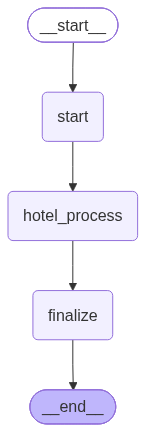

In [11]:
try:
    print("\n--- GRAPH VISUALIZATION ---")
    display(Image(travel_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization requires internet access to Mermaid servers.")